# Visualize Best Agent

This notebook loads a population checkpoint (`latest.pkl`), extracts the best agent from it, displays its program code, and visualizes it playing FlappyBird with human rendering.


In [12]:
# Import required libraries
import flappy_bird_env  # noqa
import numpy as np
import os
import pickle
from pathlib import Path
from scipy.special import expit

# Disable headless mode for human rendering
os.environ.pop('SDL_VIDEODRIVER', None)

try:
    import pygame
    pygame.init()
    print("✓ Pygame initialized for human rendering")
except Exception as e:
    print(f"Warning: Could not initialize pygame: {e}")

import gymnasium as gym
from memory_system import MemoryConfig, MemoryType
from evaluator import FlappyBirdEvaluator, FlappyBirdEvaluatorConfig


✓ Pygame initialized for human rendering


## Load Best Agent from Population Checkpoint

Load the checkpoint file (`latest.pkl`) which contains a population, then extract the best agent from it.


In [13]:
# Path to checkpoint file (contains a population)
checkpoint_path = "quantized_best.pkl"

# Import EvolutionEngine to load checkpoint
from evolution_engine import EvolutionEngine

# Check if file exists
if not Path(checkpoint_path).exists():
    print(f"❌ Checkpoint file not found: {checkpoint_path}")
    print("Please update checkpoint_path to point to your checkpoint pickle file.")
    best_agent = None
    generation = None
    population = None
else:
    print(f"Loading checkpoint from: {checkpoint_path}")
    
    # Load the checkpoint (contains population and metadata)
    checkpoint = EvolutionEngine.load_checkpoint(checkpoint_path)
    population = checkpoint['population']
    generation = checkpoint.get('generation', 'unknown')
    checkpoint_fitness = checkpoint.get('fitness', None)
    
    print(f"✓ Checkpoint loaded successfully!")
    print(f"  Generation: {generation}")
    if checkpoint_fitness is not None:
        print(f"  Best fitness in checkpoint: {checkpoint_fitness:.4f}")
    print(f"  Population size: {len(population)}")
    
    # Get the best agent from the population
    # Prefer best_ever if available (best agent across all generations)
    if population.best_ever is not None:
        best_agent = population.best_ever
        best_generation = population.best_ever_generation
        print(f"  Using best_ever agent (found at generation {best_generation})")
    else:
        best_agent = population.get_best()
        print(f"  Using best agent from current generation")
    
    print(f"\n✓ Best agent extracted!")
    print(f"  Agent ID: {best_agent.id}")
    if best_agent.fitness is not None:
        print(f"  Fitness: {best_agent.fitness:.4f}")
    else:
        print(f"  Fitness: not set")
    print(f"  Program length: {len(best_agent.program)}")
    print(f"  Age: {best_agent.age}")
    if best_agent.parent_ids:
        print(f"  Parent IDs: {best_agent.parent_ids}")


Loading checkpoint from: quantized_best.pkl
✓ Checkpoint loaded successfully!
  Generation: 567
  Best fitness in checkpoint: 1.1474
  Population size: 500
  Using best_ever agent (found at generation 567)

✓ Best agent extracted!
  Agent ID: 255632
  Fitness: 1.1474
  Program length: 56
  Age: 0
  Parent IDs: (254846, 161896)


## Display Program Code

Show the full program and the effective program (with introns removed).


In [14]:
# Reconstruct MemoryConfig from the agent's MemoryBank
# This is needed for instruction string formatting - use agent's ACTUAL dimensions!
memory = best_agent.memory
memory_cfg = MemoryConfig(
    n_scalar=memory.n_scalar,
    n_vector=8
    ,
    n_matrix=8,
    n_obs_scalar=memory.n_obs_scalar,
    n_obs_vector=memory.n_obs_vector,
    n_obs_matrix=memory.n_obs_matrix,
    vector_size=memory.vector_size,
    matrix_shape=memory.matrix_shape,
)

# Output registers (default for FlappyBird, adjust if your config uses different)
output_registers = [(MemoryType.SCALAR, 0)]

print("="*80)
print("FULL PROGRAM")
print("="*80)
print()

for i, instr in enumerate(best_agent.program.instructions):
    print(f"{i:4d}: {instr.to_resolved_str(memory_cfg)}")

print()
print("="*80)
print(f"Total: {len(best_agent.program)} instructions")
print("="*80)


FULL PROGRAM

   0: scalar[0→0] = automl_scalar_add(scalar[3386→2], obs_matrix[0→0][7383→(15,12)])
   1: matrix[5→5] = automl_matrix_add(matrix[7546→2], matrix[4104→0])
   2: scalar[0→0] = automl_scalar_heaviside(obs_matrix[0→0][9971→(12,17)])
   3: scalar[2→2] = automl_vector_mean(obs_matrix[0→0][:,721→7])
   4: scalar[4→4] = scalar_conditional(obs_matrix[0→0][6247→(3,10)], scalar[6428→4])
   5: scalar[5→5] = automl_vector_norm(obs_matrix[0→0][:,3220→7])
   6: scalar[4→4] = automl_scalar_add(obs_matrix[0→0][5603→(14,17)], scalar[4240→0])
   7: scalar[4→4] = automl_vector_norm(obs_matrix[0→0][:,8136→9])
   8: scalar[0→0] = automl_vector_mean(vector[4113→1])
   9: scalar[5→5] = automl_scalar_mul(scalar[9549→5], obs_matrix[0→0][8986→(7,19)])
  10: matrix[6→6] = automl_matrix_add(obs_matrix[0→0], matrix[2113→1])
  11: scalar[7→7] = automl_vector_dot(obs_matrix[0→0][:,195→6], vector[9891→3])
  12: scalar[6→6] = automl_scalar_heaviside(obs_matrix[0→0][471→(1,9)])
  13: scalar[2→2] = automl_

In [15]:
# Show effective program (with introns removed)
effective_program = best_agent.get_effective_program(output_registers)

print("="*80)
print("EFFECTIVE PROGRAM (INTRONS REMOVED)")
print("="*80)
print()

if len(effective_program.instructions) > 0:
    for i, instr in enumerate(effective_program.instructions):
        print(f"{i:4d}: {instr.to_resolved_str(memory_cfg)}")
else:
    print("  (No effective instructions found)")

print()
print("="*80)
print(f"Effective: {len(effective_program)} instructions (out of {len(best_agent.program)} total)")
if len(best_agent.program) > 0:
    effective_ratio = len(effective_program) / len(best_agent.program)
    print(f"Effective code rate: {effective_ratio:.3f} ({effective_ratio*100:.1f}%)")
print("="*80)


EFFECTIVE PROGRAM (INTRONS REMOVED)

   0: scalar[0→0] = scalar_conditional(obs_matrix[1→1][7049→(20,14)], scalar[960→0])

Effective: 1 instructions (out of 56 total)
Effective code rate: 0.018 (1.8%)


## Create Evaluator with Human Rendering

Set up the FlappyBird evaluator with human rendering mode to visualize the agent playing.


In [16]:
# Check agent's memory dimensions to determine training strategy
print(f"Agent's vector size: {best_agent.memory.vector_size}")
print(f"Agent's matrix shape: {best_agent.memory.matrix_shape}")

# Determine strategy based on checkpoint filename first (most reliable)
# Both quantized and trinary can produce 21x21 matrices, so we can't distinguish by dimensions alone
checkpoint_path_lower = checkpoint_path.lower()
if "quantized" in checkpoint_path_lower:
    strategy = "quantized"
    print(f"✓ Detected: Agent was trained with 'quantized' strategy (from filename: {checkpoint_path})")
elif "trinary" in checkpoint_path_lower:
    strategy = "trinary"
    print(f"✓ Detected: Agent was trained with 'trinary' strategy (from filename: {checkpoint_path})")
elif best_agent.memory.matrix_shape == (21, 21) and best_agent.memory.vector_size == 21:
    # Both quantized and trinary can be 21x21, default to quantized if ambiguous
    strategy = "quantized"
    print("⚠️  WARNING: Could not determine strategy from filename. Both quantized and trinary use 21x21 matrices.")
    print("   Defaulting to 'quantized'. If this is wrong, please specify strategy manually.")
else:
    strategy = "feature_vector"
    print(f"✓ Detected: Agent was trained with '{strategy}' strategy (from memory dimensions)")

# Create evaluator config for visualization
# Use the same config as training, but with human rendering
evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=3,  # Run 3 episodes to see the agent play
    max_steps=500,
    output_register=0,
    render_mode="human",  # Human rendering to see the game
    rng_seed=3,  # CRITICAL: Must match training seed! Training used random_seed=3
    patch_strategy=strategy,  # Match the training strategy
    color_channel=2,  # Color channel for quantized strategy (0=R, 1=G, 2=B)
    normalize=False,  # Match training config (quantized with normalize=False)
    quantization_factor=0.03,  # Downsampling factor for quantized strategy
    quantized_final_size=21,  # Final matrix size (21x21) for quantized
    feature_vector_size=64,  # Not used for quantized/trinary
    frame_stack_size=2,  # CRITICAL: Must match training! Agent expects 2 stacked frames
    action_repeat=1,  # CRITICAL: Must match training! Default is 1 (decision every frame)
    # Trinary strategy parameters (not used for quantized, but kept for compatibility)
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    output_registers=[(MemoryType.SCALAR, 0)],
    n_jobs=1,  # Sequential for visualization
)

print("\nCreating FlappyBird evaluator with human rendering...")
evaluator = FlappyBirdEvaluator(config=evaluator_config)
print("✓ Evaluator created!")
print(f"  Episodes: {evaluator.episodes}")
print(f"  Max steps per episode: {evaluator.max_steps}")
print(f"  Render mode: {evaluator.config.render_mode}")
print(f"  Patch strategy: {strategy}")
print()
print("⚠️  NOTE: FlappyBird windows will appear when you run the next cell!")
print("   Close the windows or press Ctrl+C to stop.")


Agent's vector size: 21
Agent's matrix shape: (21, 21)
✓ Detected: Agent was trained with 'quantized' strategy (from filename: quantized_best.pkl)

Creating FlappyBird evaluator with human rendering...
✓ Evaluator created!
  Episodes: 3
  Max steps per episode: 500
  Render mode: human
  Patch strategy: quantized

⚠️  NOTE: FlappyBird windows will appear when you run the next cell!
   Close the windows or press Ctrl+C to stop.


## Evaluate Agent Fitness (Proper Method)

First, let's evaluate the agent using the evaluator's `evaluate` method, which matches the training evaluation exactly. This will give us the correct fitness score.


In [17]:
# Create a proper evaluator config for testing (matches training exactly)
# Use rgb_array rendering for faster evaluation
test_evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=5,  # Match training: 5 episodes
    max_steps=500,
    output_register=0,
    render_mode="rgb_array",  # Faster than human rendering
    rng_seed=3,  # CRITICAL: Must match training seed! Training used random_seed=3
    patch_strategy=strategy,
    color_channel=2,
    normalize=False,
    quantization_factor=0.03,
    quantized_final_size=21,  # Final matrix size (21x21) for quantized
    feature_vector_size=64,
    frame_stack_size=2,  # Match training
    action_repeat=1,  # Match training (default is 1)
    # Trinary strategy parameters (not used for quantized, but kept for compatibility)
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    output_registers=[(MemoryType.SCALAR, 0)],
    n_jobs=1,
)

print("Creating test evaluator (matches training config)...")
test_evaluator = FlappyBirdEvaluator(config=test_evaluator_config)
print("✓ Test evaluator created!")

# Evaluate using the proper method (matches training exactly)
print("\nEvaluating agent using evaluator.evaluate() method...")
print("This matches the training evaluation exactly.\n")

fitness = test_evaluator.evaluate(best_agent)

print("="*80)
print("EVALUATION RESULTS")
print("="*80)
print(f"Agent fitness (from evaluator.evaluate()): {fitness:.4f}")
print(f"Agent fitness (from checkpoint): {best_agent.fitness:.4f}")
print(f"Difference: {abs(fitness - best_agent.fitness):.4f}")
print("="*80)

test_evaluator.close()


Creating test evaluator (matches training config)...
✓ Test evaluator created!

Evaluating agent using evaluator.evaluate() method...
This matches the training evaluation exactly.

EVALUATION RESULTS
Agent fitness (from evaluator.evaluate()): 0.7106
Agent fitness (from checkpoint): 1.1474
Difference: 0.4368


## Visualize Agent Playing

Run the agent and watch it play FlappyBird. The game windows will appear showing the agent's performance.


In [18]:
# Run the agent and visualize
print("="*80)
print("RUNNING BEST AGENT")
print("="*80)
print()

total_reward = 0.0
episode_rewards = []

for episode_idx in range(evaluator.episodes):
    print(f"\nEpisode {episode_idx + 1}/{evaluator.episodes}")
    print("-" * 80)
    
    # Seed the episode
    # CRITICAL: Match evaluator's seed calculation exactly: rng_seed + episode_idx
    episode_seed = evaluator.config.rng_seed + episode_idx if evaluator.config.rng_seed is not None else None
    observation, _ = evaluator.env.reset(seed=episode_seed)
    observation = np.asarray(observation, dtype=np.float32)
    
    # Reset evaluator's frame buffer for this episode (important for trinary/quantized strategies)
    evaluator.frame_buffer = None
    
    # Copy memory for this episode (preserves evolved constants in working registers)
    # Observations will be loaded fresh each step, so no need to reset observation registers
    memory = best_agent.memory.copy()
    episode_reward = 0.0
    steps = 0
    
    for step in range(evaluator.max_steps):
        # CRITICAL: Only make a decision every action_repeat frames (matches evaluator behavior)
        if step % evaluator.action_repeat == 0:
            # Process observation
            # Note: _process_observation returns different formats based on strategy:
            # - feature_vector: returns dict {'vector': [...], 'matrix': [...]}
            # - quantized/full_image: returns tuple (observations_list, 'matrix')
            result = evaluator._process_observation(observation)
            
            # Load observations into memory
            if isinstance(result, dict):
                # feature_vector strategy returns both vector and matrix
                memory.load_observation(result)
            else:
                # quantized/full_image strategy returns tuple
                processed_observations, obs_type = result
                if obs_type == 'vector':
                    memory.load_observation({'vector': processed_observations})
                else:
                    memory.load_observation({'matrix': processed_observations})
            
            # Execute the program
            best_agent.program.execute(memory, debug=True)
            
            # Read action from output register
            action_value = memory.read_scalar(evaluator.output_register)
            normalized = expit(action_value)  # Sigmoid
            action = 1 if normalized >= 0.5 else 0
        else:
            # Use NOOP (action 0) for frames between decisions (matches evaluator behavior)
            action = 0
        
        # Take step in environment
        observation, reward, terminated, truncated, _ = evaluator.env.step(action)
        observation = np.asarray(observation, dtype=np.float32)
        episode_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
    
    episode_rewards.append(episode_reward)
    total_reward += episode_reward
    
    print(f"  Steps: {steps}")
    print(f"  Reward: {episode_reward:.2f}")
    print(f"  Action value (scalar[0]): {action_value:.4f}")
    print(f"  Normalized (sigmoid): {normalized:.4f}")
    print(f"  Action chosen: {'FLAP' if action == 1 else 'NOOP'}")

print()
print("="*80)
print("SUMMARY")
print("="*80)
print(f"Total episodes: {evaluator.episodes}")
print(f"Average reward: {total_reward / evaluator.episodes:.2f}")
print(f"Rewards per episode: {[f'{r:.2f}' for r in episode_rewards]}")
print("="*80)

# Close the evaluator
evaluator.close()
print("\n✓ Visualization complete!")


RUNNING BEST AGENT


Episode 1/3
--------------------------------------------------------------------------------
Executing instruction 0: scalar[0] = automl_scalar_add(scalar[3386], obs_matrix[0]→scalar[7383])
Executing instruction 1: matrix[5] = automl_matrix_add(matrix[7546], matrix[4104])
Executing instruction 2: scalar[0] = automl_scalar_heaviside(obs_matrix[0]→scalar[9971])
Executing instruction 3: scalar[2] = automl_vector_mean(obs_matrix[0]→vector[721])
Executing instruction 4: scalar[4] = scalar_conditional(obs_matrix[0]→scalar[6247], scalar[6428])
Executing instruction 5: scalar[5] = automl_vector_norm(obs_matrix[0]→vector[3220])
Executing instruction 6: scalar[4] = automl_scalar_add(obs_matrix[0]→scalar[5603], scalar[4240])
Executing instruction 7: scalar[4] = automl_vector_norm(obs_matrix[0]→vector[8136])
Executing instruction 8: scalar[0] = automl_vector_mean(vector[4113])
Executing instruction 9: scalar[5] = automl_scalar_mul(scalar[9549], obs_matrix[0]→scalar[8986])
Exec

## Additional Information

Display additional details about the best agent's memory and constants.


In [19]:
# Display memory information
print("="*80)
print("BEST AGENT MEMORY INFORMATION")
print("="*80)
print()

memory = best_agent.memory

print("Scalar registers (working):")
for i in range(min(8, memory.n_scalar)):
    print(f"  scalar[{i}]: {memory.scalars[i]:.6f}")

print()
print("Vector registers (working):")
for i in range(min(3, memory.n_vector)):
    vec_str = ", ".join([f"{v:.3f}" for v in memory.vectors[i][:5]])
    if len(memory.vectors[i]) > 5:
        vec_str += "..."
    print(f"  vector[{i}]: [{vec_str}]")

print()
print("Matrix registers (working):")
for i in range(min(3, memory.n_matrix)):
    print(f"  matrix[{i}]: shape {memory.matrices[i].shape}, "
          f"mean={memory.matrices[i].mean():.4f}, "
          f"std={memory.matrices[i].std():.4f}")

print()
print("Observation registers:")
if memory.n_obs_matrix > 0:
    print(f"  obs_matrix[0]: shape {memory.obs_matrices[0].shape}")

print("="*80)


BEST AGENT MEMORY INFORMATION

Scalar registers (working):
  scalar[0]: 0.732815
  scalar[1]: -1.358344
  scalar[2]: -0.413583
  scalar[3]: 2.084961
  scalar[4]: -2.758069
  scalar[5]: -1.394787
  scalar[6]: -1.301240
  scalar[7]: 1.074448

Vector registers (working):
  vector[0]: [1.660, -1.880, -2.471, 1.223, -4.394...]
  vector[1]: [-0.842, 1.471, 1.145, 1.627, 0.117...]
  vector[2]: [-1.801, 0.411, -1.359, -0.122, 2.359...]

Matrix registers (working):
  matrix[0]: shape (21, 21), mean=0.1225, std=1.1741
  matrix[1]: shape (21, 21), mean=-0.0098, std=0.9999
  matrix[2]: shape (21, 21), mean=-0.0320, std=1.1551

Observation registers:
  obs_matrix[0]: shape (21, 21)


## Action Distribution Analysis

Analyze the action distribution of the best agent - how often it chooses to flap vs. not flap.


In [20]:
# Analyze action distribution for the best agent
print("="*80)
print("ACTION DISTRIBUTION ANALYSIS")
print("="*80)
print()

# Create a new evaluator config for analysis (no human rendering, faster)
analysis_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=10,  # Run more episodes for better statistics
    max_steps=500,
    output_register=0,
    render_mode="rgb_array",  # No human rendering for speed
    rng_seed=42,
    patch_strategy=strategy,  # Use detected strategy
    color_channel=2,
    normalize=False,
    quantization_factor=0.03,
    feature_vector_size=64,
    frame_stack_size=2,  # CRITICAL: Must match training!
    # Trinary strategy parameters (match training config)
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    output_registers=[(MemoryType.SCALAR, 0)],
    n_jobs=1,
)

analysis_evaluator = FlappyBirdEvaluator(config=analysis_config)

# Track actions across all episodes
all_actions = []
all_action_values = []
all_normalized_values = []
episode_rewards = []
episode_actions_list = []  # Store actions per episode for detailed analysis

print("Running agent for action distribution analysis...")
print()

for episode_idx in range(analysis_evaluator.episodes):
    # Seed the episode
    episode_seed = int((analysis_evaluator.config.rng_seed + episode_idx * 100) % (2**31))
    observation, _ = analysis_evaluator.env.reset(seed=episode_seed)
    observation = np.asarray(observation, dtype=np.float32)
    
    # Reset frame buffer
    analysis_evaluator.frame_buffer = None
    
    # Copy memory for this episode
    memory = best_agent.memory.copy()
    episode_reward = 0.0
    episode_actions = []
    episode_action_values = []
    episode_normalized = []
    
    for step in range(analysis_evaluator.max_steps):
        # Process observation
        result = analysis_evaluator._process_observation(observation)
        
        # Load observations into memory
        if isinstance(result, dict):
            memory.load_observation(result)
        else:
            processed_observations, obs_type = result
            if obs_type == 'vector':
                memory.load_observation({'vector': processed_observations})
            else:
                memory.load_observation({'matrix': processed_observations})
        
        # Execute the program (no debug output)
        best_agent.program.execute(memory)
        
        # Read action from output register
        action_value = memory.read_scalar(analysis_evaluator.output_register)
        normalized = expit(action_value)  # Sigmoid
        action = 1 if normalized >= 0.5 else 0
        
        # Track actions
        episode_actions.append(action)
        episode_action_values.append(action_value)
        episode_normalized.append(normalized)
        all_actions.append(action)
        all_action_values.append(action_value)
        all_normalized_values.append(normalized)
        
        # Take step in environment
        observation, reward, terminated, truncated, _ = analysis_evaluator.env.step(action)
        observation = np.asarray(observation, dtype=np.float32)
        episode_reward += reward
        
        if terminated or truncated:
            break
    
    episode_rewards.append(episode_reward)
    episode_actions_list.append(episode_actions)  # Store for per-episode analysis
    flap_rate = 100*sum(episode_actions)/len(episode_actions) if len(episode_actions) > 0 else 0
    print(f"Episode {episode_idx + 1}: {len(episode_actions)} steps, "
          f"Reward: {episode_reward:.2f}, "
          f"Actions: {sum(episode_actions)} flaps / {len(episode_actions)} total "
          f"({flap_rate:.1f}% flap rate)")

analysis_evaluator.close()

print()
print("="*80)
print("ACTION DISTRIBUTION SUMMARY")
print("="*80)
print()

total_steps = len(all_actions)
flap_count = sum(all_actions)
noop_count = total_steps - flap_count
flap_percentage = 100 * flap_count / total_steps if total_steps > 0 else 0
noop_percentage = 100 * noop_count / total_steps if total_steps > 0 else 0

print(f"Total steps analyzed: {total_steps}")
print(f"Episodes: {analysis_evaluator.episodes}")
print()
print("Action Distribution:")
print(f"  FLAP (action=1):  {flap_count:6d} steps ({flap_percentage:5.2f}%)")
print(f"  NOOP (action=0):  {noop_count:6d} steps ({noop_percentage:5.2f}%)")
print()

# Action value statistics
action_values_array = np.array(all_action_values)
normalized_array = np.array(all_normalized_values)

print("Action Value Statistics (from scalar[0]):")
print(f"  Mean:   {action_values_array.mean():.4f}")
print(f"  Std:    {action_values_array.std():.4f}")
print(f"  Min:    {action_values_array.min():.4f}")
print(f"  Max:    {action_values_array.max():.4f}")
print(f"  Median: {np.median(action_values_array):.4f}")
print()

print("Normalized Value Statistics (after sigmoid):")
print(f"  Mean:   {normalized_array.mean():.4f}")
print(f"  Std:    {normalized_array.std():.4f}")
print(f"  Min:    {normalized_array.min():.4f}")
print(f"  Max:    {normalized_array.max():.4f}")
print(f"  Median: {np.median(normalized_array):.4f}")
print()

# Reward statistics
rewards_array = np.array(episode_rewards)
print("Reward Statistics:")
print(f"  Mean reward per episode:   {rewards_array.mean():.4f}")
print(f"  Std reward per episode:    {rewards_array.std():.4f}")
print(f"  Min reward per episode:    {rewards_array.min():.4f}")
print(f"  Max reward per episode:    {rewards_array.max():.4f}")
print(f"  Total reward:              {rewards_array.sum():.4f}")
print()

# Action pattern analysis
print("Action Pattern Analysis:")
consecutive_flaps = 0
max_consecutive_flaps = 0
consecutive_noops = 0
max_consecutive_noops = 0

for i, action in enumerate(all_actions):
    if action == 1:
        consecutive_flaps += 1
        consecutive_noops = 0
        max_consecutive_flaps = max(max_consecutive_flaps, consecutive_flaps)
    else:
        consecutive_noops += 1
        consecutive_flaps = 0
        max_consecutive_noops = max(max_consecutive_noops, consecutive_noops)

print(f"  Max consecutive flaps:  {max_consecutive_flaps}")
print(f"  Max consecutive noops:  {max_consecutive_noops}")
print()

# Flap rate per episode
print("Flap Rate Per Episode:")
for i, episode_actions in enumerate(episode_actions_list):
    episode_flaps = sum(episode_actions)
    episode_total = len(episode_actions)
    episode_flap_rate = 100 * episode_flaps / episode_total if episode_total > 0 else 0
    print(f"  Episode {i+1}: {episode_flaps}/{episode_total} flaps ({episode_flap_rate:.1f}%) - Reward: {episode_rewards[i]:.2f}")

# Simple visualization
print("="*80)
print("VISUALIZATION")
print("="*80)
print()

# Create a simple bar chart using text
bar_length = 50
flap_bars = int(flap_percentage / 100 * bar_length)
noop_bars = bar_length - flap_bars

print("Action Distribution (visual):")
print(f"  FLAP: {'█' * flap_bars} {flap_percentage:.1f}%")
print(f"  NOOP: {'█' * noop_bars} {noop_percentage:.1f}%")
print()

# Threshold analysis
threshold = 0.5
above_threshold = np.sum(normalized_array >= threshold)
below_threshold = np.sum(normalized_array < threshold)

print(f"Normalized values >= 0.5 (would flap):  {above_threshold} ({100*above_threshold/len(normalized_array):.2f}%)")
print(f"Normalized values < 0.5 (would noop):   {below_threshold} ({100*below_threshold/len(normalized_array):.2f}%)")
print()

print("="*80)


ACTION DISTRIBUTION ANALYSIS

Running agent for action distribution analysis...

Episode 1: 83 steps, Reward: 0.08, Actions: 7 flaps / 83 total (8.4% flap rate)
Episode 2: 83 steps, Reward: 0.08, Actions: 7 flaps / 83 total (8.4% flap rate)
Episode 3: 87 steps, Reward: 0.09, Actions: 9 flaps / 87 total (10.3% flap rate)
Episode 4: 86 steps, Reward: 0.09, Actions: 9 flaps / 86 total (10.5% flap rate)
Episode 5: 93 steps, Reward: 0.09, Actions: 14 flaps / 93 total (15.1% flap rate)
Episode 6: 94 steps, Reward: 0.09, Actions: 7 flaps / 94 total (7.4% flap rate)
Episode 7: 83 steps, Reward: 0.08, Actions: 7 flaps / 83 total (8.4% flap rate)
Episode 8: 96 steps, Reward: 1.09, Actions: 17 flaps / 96 total (17.7% flap rate)
Episode 9: 83 steps, Reward: 0.08, Actions: 7 flaps / 83 total (8.4% flap rate)
Episode 10: 94 steps, Reward: 0.09, Actions: 7 flaps / 94 total (7.4% flap rate)

ACTION DISTRIBUTION SUMMARY

Total steps analyzed: 882
Episodes: 10

Action Distribution:
  FLAP (action=1):   

In [21]:
# Self-contained cell: Modify program and print obs_matrix[1] values
import numpy as np
from instruction import Instruction
from program import Program
from memory_system import MemoryType
from operation import AutoMLScalarSinOp, AutoMLScalarDivOp, ScalarConditionalOp
from scipy.special import expit

# Create the required operations

sin_op = AutoMLScalarSinOp()
div_op = AutoMLScalarDivOp()
conditional_op = ScalarConditionalOp()

print(f"Found operations:")
print(f"  sin: {sin_op.name}")
print(f"  div: {div_op.name}")
print(f"  conditional: {conditional_op.name}")
print()

# Matrix is 21x21, so flat indices:
# (16, 10) -> 16*21 + 10 = 346
# (3, 0) -> 3*21 + 0 = 63
# (20, 14) -> 20*21 + 14 = 434

# But we'll use the large indices as specified: 9607, 2268, 7049
# These will wrap to the correct positions

# Create the three instructions
# 1. scalar[3] = automl_scalar_sin(obs_matrix[1][(16,10)])
instr1 = Instruction(
    operation=sin_op,
    dest_type=MemoryType.SCALAR,
    dest_index=3,
    source_types=[MemoryType.SCALAR],
    source_indices=[9607],  # Will decode to (16,10) in 21x21 matrix
    source_obs_flags=[True],
    source_obs_register_types=[MemoryType.MATRIX],
    source_obs_register_indices=[1]
)

# 2. scalar[0] = automl_scalar_div(obs_matrix[1][(3,0)], scalar[3])
instr2 = Instruction(
    operation=div_op,
    dest_type=MemoryType.SCALAR,
    dest_index=0,
    source_types=[MemoryType.SCALAR, MemoryType.SCALAR],
    source_indices=[2268, 875],  # 2268 -> (3,0), 875 -> scalar[3] (wrapped)
    source_obs_flags=[True, False],
    source_obs_register_types=[MemoryType.MATRIX, MemoryType.SCALAR],
    source_obs_register_indices=[1, 0]  # obs_matrix[1], scalar[3] (875 % 8 = 3)
)

# 3. scalar[0] = scalar_conditional(obs_matrix[1][(20,14)], scalar[0])
instr3 = Instruction(
    operation=conditional_op,
    dest_type=MemoryType.SCALAR,
    dest_index=0,
    source_types=[MemoryType.SCALAR, MemoryType.SCALAR],
    source_indices=[7049, 960],  # 7049 -> (20,14), 960 -> scalar[0] (wrapped)
    source_obs_flags=[True, False],
    source_obs_register_types=[MemoryType.MATRIX, MemoryType.SCALAR],
    source_obs_register_indices=[1, 0]  # obs_matrix[1], scalar[0] (960 % 8 = 0)
)

# Create new program with these 3 instructions
new_program = Program([instr1, instr2, instr3])

# Replace best_agent's program
best_agent.program = new_program

print("✓ Program replaced with 3 instructions:")
print("  1. scalar[3] = automl_scalar_sin(obs_matrix[1][(16,10)])")
print("  2. scalar[0] = automl_scalar_div(obs_matrix[1][(3,0)], scalar[3])")
print("  3. scalar[0] = scalar_conditional(obs_matrix[1][(20,14)], scalar[0])")
print()

# Create evaluator config
evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=1,
    max_steps=500,
    output_register=0,
    render_mode="rgb_array",
    rng_seed=0,
    patch_strategy=strategy,
    color_channel=2,
    normalize=False,
    quantization_factor=0.03,
    feature_vector_size=64,
    frame_stack_size=2,
    action_repeat=1,
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    output_registers=[(MemoryType.SCALAR, 0)],
    n_jobs=1,
)

evaluator = FlappyBirdEvaluator(config=evaluator_config)

# Run one episode and print values
print("="*80)
print("RUNNING ONE EPISODE - PRINTING OBS_MATRIX[1] VALUES")
print("="*80)
print()

observation, _ = evaluator.env.reset(seed=3)
observation = np.asarray(observation, dtype=np.float32)
evaluator.frame_buffer = None
memory = best_agent.memory.copy()
episode_reward = 0.0

# Track positions: (16,10), (3,0), (20,14)
pos1 = (16, 10)
pos2 = (3, 0)
pos3 = (20, 14)

print(f"Tracking obs_matrix[1] at positions: {pos1}, {pos2}, {pos3}")
print()
print("Step | (16,10) | (3,0)  | (20,14) | Instr1[sin] | Instr2[div] | Instr3[cond] | Action | Reward")
print("-" * 120)

for step in range(evaluator.max_steps):
    if step % evaluator.action_repeat == 0:
        # Process observation
        result = evaluator._process_observation(observation)
        processed_observations, obs_type = result
        memory.load_observation({'matrix': processed_observations})
        
        # Get values BEFORE execution
        obs_matrix_1 = memory.obs_matrices[1]
        val1 = obs_matrix_1[pos1[0], pos1[1]]
        val2 = obs_matrix_1[pos2[0], pos2[1]]
        val3 = obs_matrix_1[pos3[0], pos3[1]]
        
        # Execute instructions one by one to track intermediate values
        # Instruction 1: scalar[3] = automl_scalar_sin(obs_matrix[1][(16,10)])
        best_agent.program.instructions[0].execute(memory)
        instr1_result = memory.read_scalar(3)  # scalar[3] after sin
        
        # Instruction 2: scalar[0] = automl_scalar_div(obs_matrix[1][(3,0)], scalar[3])
        best_agent.program.instructions[1].execute(memory)
        instr2_result = memory.read_scalar(0)  # scalar[0] after div
        
        # Instruction 3: scalar[0] = scalar_conditional(obs_matrix[1][(20,14)], scalar[0])
        best_agent.program.instructions[2].execute(memory)
        instr3_result = memory.read_scalar(0)  # scalar[0] after conditional (final output)
        
        # Read action
        action_value = instr3_result  # This is already scalar[0]
        normalized = expit(action_value)
        action = 1 if normalized >= 0.5 else 0
    else:
        action = 0
        val1 = val2 = val3 = None  # No new observation
        instr1_result = instr2_result = instr3_result = None
    
    # Take step
    observation, reward, terminated, truncated, _ = evaluator.env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    episode_reward += reward
    
    # Print values (only when we processed observation)
    if step % evaluator.action_repeat == 0:
        print(f"{step:4d} | {val1:7.3f} | {val2:6.3f} | {val3:7.3f} | {instr1_result:11.6f} | {instr2_result:11.6f} | {instr3_result:12.6f} | {'FLAP' if action == 1 else 'NOOP':5s} | {reward:6.2f}")
    
    if terminated or truncated:
        print(f"\nEpisode ended at step {step}")
        break

print()
print("="*80)
print(f"Total reward: {episode_reward:.2f}")
print("="*80)

evaluator.close()


Found operations:
  sin: automl_scalar_sin
  div: automl_scalar_div
  conditional: scalar_conditional

✓ Program replaced with 3 instructions:
  1. scalar[3] = automl_scalar_sin(obs_matrix[1][(16,10)])
  2. scalar[0] = automl_scalar_div(obs_matrix[1][(3,0)], scalar[3])
  3. scalar[0] = scalar_conditional(obs_matrix[1][(20,14)], scalar[0])

RUNNING ONE EPISODE - PRINTING OBS_MATRIX[1] VALUES

Tracking obs_matrix[1] at positions: (16, 10), (3, 0), (20, 14)

Step | (16,10) | (3,0)  | (20,14) | Instr1[sin] | Instr2[div] | Instr3[cond] | Action | Reward
------------------------------------------------------------------------------------------------------------------------
   0 | 202.000 | 202.000 | 210.000 |    0.806418 |  250.490311 |  -210.000000 | NOOP  |   0.00
   1 | 202.000 | 202.000 | 210.000 |    0.806418 |  250.490311 |  -210.000000 | NOOP  |   0.00
   2 | 202.000 | 202.000 | 210.000 |    0.806418 |  250.490311 |  -210.000000 | NOOP  |   0.00
   3 | 202.000 | 202.000 | 210.000 |   

## Visualize Frames 36, 78, and 137 with Highlighted Pixels

Visualize the observation matrices at steps 36, 78, and 137, highlighting the pixels at positions (16,10), (3,0), and (20,14) that the agent's program uses.


Running episode to capture frames 36, 78, and 137...

Captured frame 36:
  (16,10) = 198.000000
  (3,0) = 202.000000
  (20,14) = 210.000000

Captured frame 78:
  (16,10) = 202.000000
  (3,0) = 202.000000
  (20,14) = 83.000000

Captured frame 137:
  (16,10) = 202.000000
  (3,0) = 147.000000
  (20,14) = 210.000000



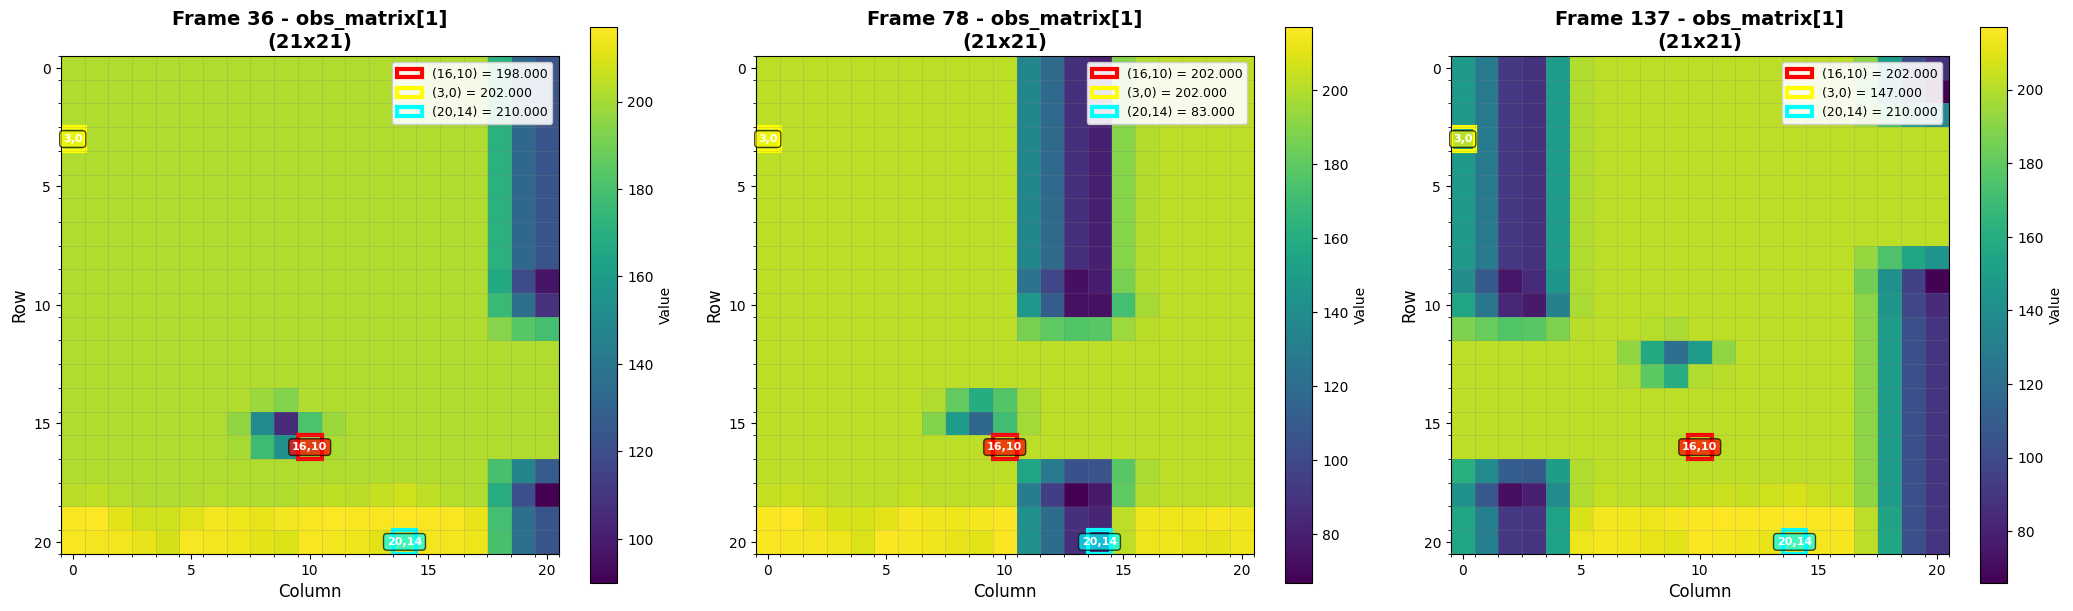

FRAME VISUALIZATION SUMMARY

Frame 36:
  (16, 10): 198.000000
  (3, 0): 202.000000
  (20, 14): 210.000000

Frame 78:
  (16, 10): 202.000000
  (3, 0): 202.000000
  (20, 14): 83.000000

Frame 137:
  (16, 10): 202.000000
  (3, 0): 147.000000
  (20, 14): 210.000000


In [23]:
# Visualize frames 36 and 78 with highlighted pixels
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create evaluator config (same as before)
viz_evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=1,
    max_steps=500,
    output_register=0,
    render_mode="rgb_array",
    rng_seed=3,  # Match the seed used in the program modification cell
    patch_strategy=strategy,
    color_channel=2,
    normalize=False,
    quantization_factor=0.03,
    quantized_final_size=21,
    feature_vector_size=64,
    frame_stack_size=2,
    action_repeat=1,
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    output_registers=[(MemoryType.SCALAR, 0)],
    n_jobs=1,
)

viz_evaluator = FlappyBirdEvaluator(config=viz_evaluator_config)

# Run one episode and capture frames at steps 36, 78, and 137
print("Running episode to capture frames 36, 78, and 137...")
print()

observation, _ = viz_evaluator.env.reset(seed=3)
observation = np.asarray(observation, dtype=np.float32)
viz_evaluator.frame_buffer = None
memory = best_agent.memory.copy()

# Positions to highlight
highlight_positions = [(16, 10), (3, 0), (20, 14)]
captured_frames = {}

for step in range(viz_evaluator.max_steps):
    if step % viz_evaluator.action_repeat == 0:
        # Process observation
        result = viz_evaluator._process_observation(observation)
        processed_observations, obs_type = result
        memory.load_observation({'matrix': processed_observations})
        
        # Capture frames at steps 36, 78, and 137
        if step == 36 or step == 78 or step == 137:
            # Get obs_matrix[1] (the second stacked frame)
            obs_matrix_1 = memory.obs_matrices[1].copy()
            captured_frames[step] = {
                'matrix': obs_matrix_1,
                'values': {
                    (16, 10): obs_matrix_1[16, 10],
                    (3, 0): obs_matrix_1[3, 0],
                    (20, 14): obs_matrix_1[20, 14]
                }
            }
            print(f"Captured frame {step}:")
            print(f"  (16,10) = {obs_matrix_1[16, 10]:.6f}")
            print(f"  (3,0) = {obs_matrix_1[3, 0]:.6f}")
            print(f"  (20,14) = {obs_matrix_1[20, 14]:.6f}")
            print()
        
        # Execute program to get action
        best_agent.program.execute(memory)
        action_value = memory.read_scalar(viz_evaluator.output_register)
        normalized = expit(action_value)
        action = 1 if normalized >= 0.5 else 0
    else:
        action = 0
    
    # Take step
    observation, reward, terminated, truncated, _ = viz_evaluator.env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        break

viz_evaluator.close()

# Visualize the captured frames
if len(captured_frames) >= 2:
    # Create subplots for 3 frames (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    
    # Sort frames by step number
    sorted_frames = sorted(captured_frames.items())
    
    for idx, (step, frame_data) in enumerate(sorted_frames):
        ax = axes[idx]
        matrix = frame_data['matrix']
        
        # Display the matrix as an image
        im = ax.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=matrix.min(), vmax=matrix.max())
        ax.set_title(f'Frame {step} - obs_matrix[1]\n(21x21)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Column', fontsize=12)
        ax.set_ylabel('Row', fontsize=12)
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Value')
        
        # Highlight the three positions
        colors = ['red', 'yellow', 'cyan']
        labels = ['(16,10)', '(3,0)', '(20,14)']
        
        for pos_idx, (pos, color, label) in enumerate(zip(highlight_positions, colors, labels)):
            row, col = pos
            value = frame_data['values'][pos]
            
            # Draw a rectangle around the pixel
            rect = patches.Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                linewidth=3, edgecolor=color, facecolor='none',
                label=f'{label} = {value:.3f}'
            )
            ax.add_patch(rect)
            
            # Add text annotation
            ax.text(col, row, f'{pos[0]},{pos[1]}', 
                   ha='center', va='center', fontsize=8, fontweight='bold',
                   color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7))
        
        # Add grid for better visibility
        ax.set_xticks(np.arange(-0.5, 21, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 21, 1), minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.set_xticks(np.arange(0, 21, 5))
        ax.set_yticks(np.arange(0, 21, 5))
        
        # Add legend
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("="*80)
    print("FRAME VISUALIZATION SUMMARY")
    print("="*80)
    for step, frame_data in sorted(captured_frames.items()):
        print(f"\nFrame {step}:")
        for pos in highlight_positions:
            value = frame_data['values'][pos]
            print(f"  {pos}: {value:.6f}")
else:
    print(f"⚠️  Warning: Only captured {len(captured_frames)} frames. Expected 3 (steps 36, 78, and 137).")
    if len(captured_frames) > 0:
        print("Captured frames:", sorted(captured_frames.keys()))
